In [3]:
%cd .. 

from src.qtt_interpolation.utils import *

c:\Users\siddhartha.morales\OneDrive - Technology Innovation Institute\Documents\GitHub


C:\Users\siddhartha.morales\AppData\Roaming\Python\Python311\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


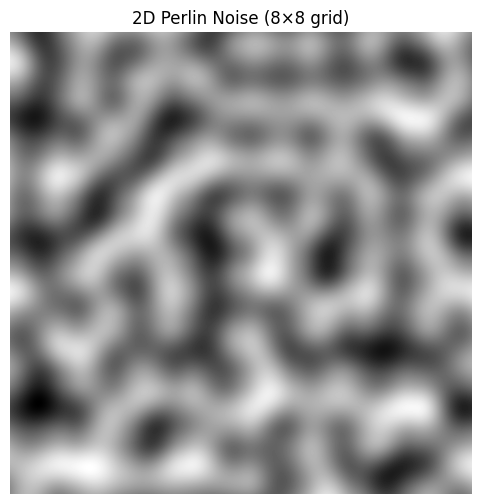

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def generate_perlin_noise_2d(shape, res, seed=None):
    """
    Generate a 2D Perlin noise array.
    shape: (height, width) of the output array.
    res: number of grid cells (grid_y, grid_x). Must divide shape.
    seed: optional integer seed for reproducibility.
    """
    if seed is not None:
        np.random.seed(seed)
    h, w = shape
    ry, rx = res
    # Grid of random gradient vectors
    theta = 2 * np.pi * np.random.rand(ry+1, rx+1)
    grads = np.stack((np.cos(theta), np.sin(theta)), axis=2)  # shape (ry+1, rx+1, 2)

    # Generate coordinate arrays
    y = np.linspace(0, ry, h, endpoint=False)
    x = np.linspace(0, rx, w, endpoint=False)
    yi = y.astype(int)
    xi = x.astype(int)
    fy = y - yi
    fx = x - xi

    # Fade curves
    def fade(t):
        return 6*t**5 - 15*t**4 + 10*t**3

    u = fade(fx)
    v = fade(fy)

    # Expand to 2D grids
    xi = np.repeat(xi[np.newaxis, :], h, axis=0)
    yi = np.repeat(yi[:, np.newaxis], w, axis=1)
    fx = np.repeat(fx[np.newaxis, :], h, axis=0)
    fy = np.repeat(fy[:, np.newaxis], w, axis=1)
    u = np.repeat(u[np.newaxis, :], h, axis=0)
    v = np.repeat(v[:, np.newaxis], w, axis=1)

    # Helper to index gradients
    def grad(i, j):
        return grads[i % ry, j % rx]

    # Corners
    g00 = grads[yi,     xi    ]
    g10 = grads[yi,     xi+1  ]
    g01 = grads[yi+1,   xi    ]
    g11 = grads[yi+1,   xi+1  ]

    # Vectors from grid points to pixel
    d00 = np.stack((fx,    fy   ), axis=2)
    d10 = np.stack((fx-1,  fy   ), axis=2)
    d01 = np.stack((fx,    fy-1 ), axis=2)
    d11 = np.stack((fx-1,  fy-1 ), axis=2)

    # Dot products
    dot00 = np.sum(g00 * d00, axis=2)
    dot10 = np.sum(g10 * d10, axis=2)
    dot01 = np.sum(g01 * d01, axis=2)
    dot11 = np.sum(g11 * d11, axis=2)

    # Linear interpolation
    def lerp(a, b, t):
        return a + t * (b - a)

    nx0 = lerp(dot00, dot10, u)
    nx1 = lerp(dot01, dot11, u)
    nxy = lerp(nx0, nx1, v)

    return nxy

# Example usage
shape = (512, 512)
res = (8, 8)
noise = generate_perlin_noise_2d(shape, res, seed=42)

plt.figure(figsize=(6, 6))
plt.title("2D Perlin Noise (8×8 grid)")
plt.imshow(noise, cmap='gray', interpolation='lanczos')
plt.axis('off')
plt.show()


Spectral slope β = 2.785, fractal exponent H = 0.893


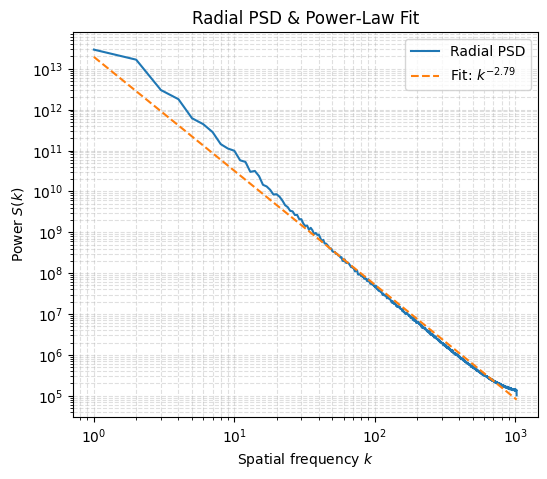

Using persistence p = 2^(-H) = 0.539
MSE (normalized) = 1.393998e-04


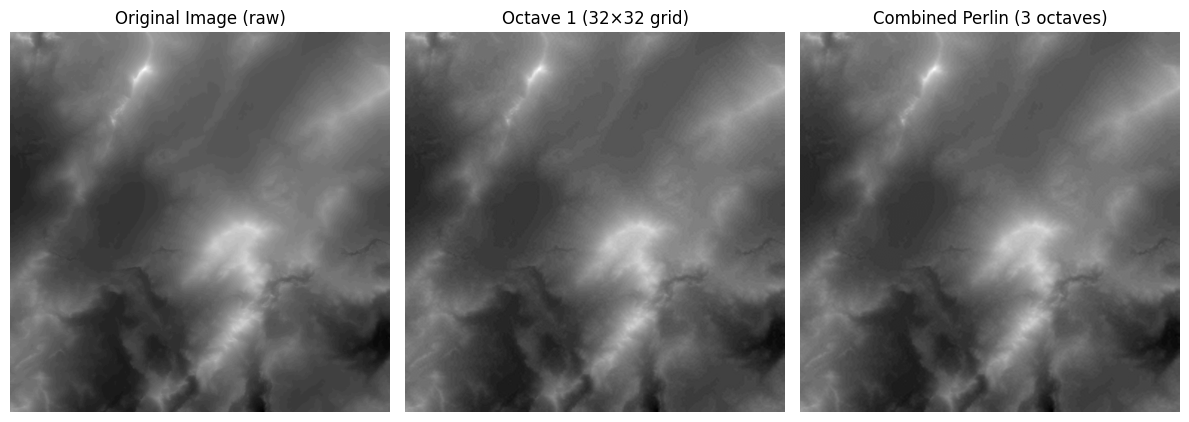

In [ ]:
import numpy as np
import imageio.v2 as imageio
import matplotlib.pyplot as plt
from scipy.ndimage import zoom as ndzoom
from scipy.fftpack import fft2, fftshift

# ---------------------------------------------
# 1) Radial PSD → log–log fit to get H and β
# ---------------------------------------------
def compute_radial_psd(img):
    """
    Compute the radial power spectral density of a 2D image.
    Returns (k_vals, radial_psd).
    """
    F2 = fftshift(fft2(img))
    P2 = np.abs(F2)**2
    ny, nx = P2.shape
    cy, cx = ny//2, nx//2
    y, x = np.indices((ny, nx))
    r = np.hypot(x - cx, y - cy).astype(int)
    max_r = min(cx, cy)
    bc = np.bincount(r.ravel(), minlength=max_r+1)[: max_r+1]
    bs = np.bincount(r.ravel(), P2.ravel(), minlength=max_r+1)[: max_r+1]
    radial_ps = bs[1:] / bc[1:]  # drop r=0 (DC)
    k_vals = np.arange(1, max_r+1)
    return k_vals, radial_ps

def fit_power_law_loglog(k, ps):
    """
    Fit ps ≈ a * k^(-beta) by linear regression on log-log scale.
    Returns (a, beta).
    """
    mask = (ps > 0)
    logk = np.log10(k[mask])
    logps = np.log10(ps[mask])
    slope, intercept = np.polyfit(logk, logps, 1)
    beta = -slope
    a = 10**intercept
    return a, beta

def compute_fractal_H(img):
    """
    Compute spectral slope beta and fractal exponent H from a 2D image.
    Returns (H, beta, k_vals, radial_ps, a_fit).
    """
    k_vals, radial_ps = compute_radial_psd(img)
    a_fit, beta = fit_power_law_loglog(k_vals, radial_ps)
    H = (beta - 1) / 2
    return H, beta, k_vals, radial_ps, a_fit

# ------------------------------------------------
# 2) Build a 32×32 “image‐derived” gradient+height grid
# ------------------------------------------------
def build_coarse_gradients_and_heights(image, base_res):
    """
    1) Downsample `image` (raw, no normalization) to `base_res` using bicubic+wrap.
    2) Compute central‐difference gradients on that coarse grid.
    3) Pad to (by+1, bx+1) and normalize each vector.
    4) Also return the coarse height‐grid z[y,x].
    
    Returns:
      grads: (by+1, bx+1, 2) array of unit‐gradients,
      heights: (by+1, bx+1) array of coarse heights (z).
    """
    h, w = image.shape
    by, bx = base_res

    # Bicubic downsample to (by × bx) with periodic wrap
    zoom_y = by / h
    zoom_x = bx / w
    coarse = ndzoom(image, (zoom_y, zoom_x), order=3, mode='wrap')
    # coarse.shape == (by, bx)

    # 1) Build the coarse height grid z[i,j]:
    heights = np.zeros((by+1, bx+1), dtype=float)
    heights[:by, :bx] = coarse
    # Tile the bottom row/col to pad:
    heights[by, :bx] = coarse[-1, :]
    heights[:by, bx] = coarse[:, -1]
    heights[by, bx] = coarse[-1, -1]

    # 2) Compute finite‐difference gradients on that coarse image:
    gy, gx = np.gradient(coarse)  # each shape (by, bx)

    # 3) Pad to (by+1, bx+1)
    grad_y = np.zeros((by+1, bx+1), dtype=float)
    grad_x = np.zeros((by+1, bx+1), dtype=float)
    grad_y[:by, :bx] = gy
    grad_x[:by, :bx] = gx
    grad_y[by, :bx] = gy[-1, :]   # bottom edge
    grad_x[by, :bx] = gx[-1, :]
    grad_y[:by, bx] = gy[:, -1]   # right edge
    grad_x[:by, bx] = gx[:, -1]
    grad_y[by, bx] = gy[-1, -1]   # bottom‐right corner
    grad_x[by, bx] = gx[-1, -1]

    # 4) Stack & normalize to unit‐length gradient vectors
    grads = np.stack([grad_x, grad_y], axis=2)  # shape (by+1, bx+1, 2)
    norms = np.linalg.norm(grads, axis=2, keepdims=True)
    norms[norms == 0] = 1.0
    grads /= norms

    return grads, heights

# --------------------------
# 3) Upsample gradient grid by 2× and re‐normalize
# --------------------------
def upsample_gradients(prev_grads):
    """
    Bicubically upsample a (Ny, Nx, 2) gradient grid → (2Ny−1, 2Nx−1, 2),
    then renormalize each vector to unit length.
    """
    from scipy.ndimage import zoom as ndzoom
    Ny, Nx, _ = prev_grads.shape
    gx = prev_grads[..., 0]
    gy = prev_grads[..., 1]

    new_Ny = 2*Ny - 1
    new_Nx = 2*Nx - 1

    gx_up = ndzoom(gx, (new_Ny/ Ny, new_Nx/ Nx), order=3, mode='wrap')
    gy_up = ndzoom(gy, (new_Ny/ Ny, new_Nx/ Nx), order=3, mode='wrap')

    grads_up = np.stack([gx_up, gy_up], axis=2)
    norms = np.linalg.norm(grads_up, axis=2, keepdims=True)
    norms[norms == 0] = 1.0
    grads_up /= norms

    return grads_up

# -------------------------------------------------------
# 4) Sample Perlin‐noise at a given frequency, adding heights
# -------------------------------------------------------
def perlin_noise_with_heights(shape, freq, gradients, heights):
    """
    Generate a 2D Perlin‐style field of size `shape = (h, w)` using
    a pre‐built gradient grid and a corresponding height‐grid.

    - `freq = (f_y, f_x)` is the number of “cells” in y/x.  
    - `gradients` must have shape (G_y+1, G_x+1, 2) with G_y > f_y, G_x > f_x.  
    - `heights` must have shape (f_y+1, f_x+1) (coarse‐grid z values)  

    For each pixel (p,q), let  
      \(\mathbf{v}_{m,n}\) = (dx, dy) from the \((i+m,\;j+n)\)-th lattice point,  
      \(\mathbf{g}_{m,n}\) = gradient at that lattice node,  
      \(z_{m,n} = \heights[i+m,\,j+n]\).  

    Then
      \(\delta_{m,n} = z_{m,n} \;+\; (\mathbf{v}_{m,n} \cdot \mathbf{g}_{m,n})\).  
    Finally, do fade‐interpolation among the four \(\delta\)-values exactly as Perlin prescribes.
    """
    h, w = shape
    f_y, f_x = freq
    G_y, G_x, _ = gradients.shape
    assert f_y < G_y and f_x < G_x
    assert heights.shape == (f_y+1, f_x+1)

    # 1) Pixel → grid‐cell mapping
    y = np.linspace(0, f_y, h, endpoint=False)
    x = np.linspace(0, f_x, w, endpoint=False)
    yi = y.astype(int)
    xi = x.astype(int)
    yf = y - yi
    xf = x - xi

    # 2) Fade curve
    def fade(t): return 6*t**5 - 15*t**4 + 10*t**3
    u1d = fade(xf)  # shape (w,)
    v1d = fade(yf)  # shape (h,)

    # 3) Expand to 2D arrays (h×w)
    yi2d = np.repeat(yi[:,None], w, axis=1)
    xi2d = np.repeat(xi[None,:], h, axis=0)
    yf2d = np.repeat(yf[:,None], w, axis=1)
    xf2d = np.repeat(xf[None,:], h, axis=0)
    u2d  = np.repeat(u1d[None,:], h, axis=0)
    v2d  = np.repeat(v1d[:,None], w, axis=1)

    # 4) Gather corner gradients and heights
    g00 = gradients[ yi2d,     xi2d    ]  # top-left
    g10 = gradients[ yi2d,     xi2d + 1]  # top-right
    g01 = gradients[ yi2d + 1, xi2d    ]  # bottom-left
    g11 = gradients[ yi2d + 1, xi2d + 1]  # bottom-right

    z00 = heights[ yi2d,     xi2d    ]
    z10 = heights[ yi2d,     xi2d + 1]
    z01 = heights[ yi2d + 1, xi2d    ]
    z11 = heights[ yi2d + 1, xi2d + 1]

    # 5) Displacement vectors from each corner to the pixel
    d00 = np.stack([xf2d,      yf2d    ], axis=2)
    d10 = np.stack([xf2d - 1,  yf2d    ], axis=2)
    d01 = np.stack([xf2d,      yf2d - 1], axis=2)
    d11 = np.stack([xf2d - 1,  yf2d - 1], axis=2)

    # 6) Dot products
    dot00 = np.sum(g00 * d00, axis=2)
    dot10 = np.sum(g10 * d10, axis=2)
    dot01 = np.sum(g01 * d01, axis=2)
    dot11 = np.sum(g11 * d11, axis=2)

    # 7) δ = height + dot‐product
    δ00 = z00 + dot00
    δ10 = z10 + dot10
    δ01 = z01 + dot01
    δ11 = z11 + dot11

    # 8) Bilinear interpolation on δ’s using fade weights
    def lerp(a, b, t):
        return a + t * (b - a)

    nx0 = lerp(δ00, δ10, u2d)
    nx1 = lerp(δ01, δ11, u2d)
    nxy = lerp(nx0, nx1, v2d)

    return nxy

# --------------------------
# 5) Main pipeline
# --------------------------

# 5.1) Load the raw full‐resolution image (no prior normalization)
image_path = "full.png"
orig_full = imageio.imread(image_path)
if orig_full.ndim == 3:
    orig_full = orig_full.mean(axis=2)
orig_full = orig_full.astype(np.float32)
h_full, w_full = orig_full.shape   # e.g. 2048×2048

# 5.2) Compute (H, β, k_vals, radial_ps, a_fit) via log‐log fit
H, beta, k_vals, radial_ps, a_fit = compute_fractal_H(orig_full)
print(f"Spectral slope β = {beta:.3f}, fractal exponent H = {H:.3f}")

# Plot the PSD and its fit
plt.figure(figsize=(6, 5))
plt.loglog(k_vals, radial_ps,            label="Radial PSD")
plt.loglog(k_vals, a_fit * k_vals**(-beta), '--',
           label=f"Fit: $k^{{-{beta:.2f}}}$")
plt.xlabel("Spatial frequency $k$")
plt.ylabel("Power $S(k)$")
plt.title("Radial PSD & Power‐Law Fit")
plt.legend()
plt.grid(which="both", ls="--", alpha=0.4)
plt.show()

# 5.3) Build a 32×32 “image–derived” gradient & height grid (no normalization)
base_res = (256, 256)
grads_coarse, heights_coarse = build_coarse_gradients_and_heights(orig_full, base_res)
# grads_coarse.shape == (33,33,2)
# heights_coarse.shape == (33,33)

# 5.4) Upsample both gradient‐grid and height‐grid for octaves 2 & 3
num_octaves = 3
gradients_list = [grads_coarse]
heights_list  = [heights_coarse]

for i in range(1, num_octaves):
    gradients_list.append(upsample_gradients(gradients_list[-1]))
    # Upsample the height‐grid by bicubic+wrap as well (so that z grid has the same shape):
    gy  = heights_list[-1]
    new_by = 2*gy.shape[0] - 1
    new_bx = 2*gy.shape[1] - 1
    up_gy = ndzoom(gy, (new_by / gy.shape[0], new_bx / gy.shape[1]), order=3, mode='wrap')
    heights_list.append(up_gy)

# 5.5) Set persistence = 2^{-H}
persistence = 2 ** (-H)
print(f"Using persistence p = 2^(-H) = {persistence:.3f}")

# 5.6) Generate combined Perlin with heights included, but do NOT normalize per octave
perlin_sum = np.zeros((h_full, w_full), dtype=np.float32)

for i in range(num_octaves):
    fy = base_res[0] * (2**i)
    fx = base_res[1] * (2**i)
    amp = persistence **i 
    # Each octave uses a gradient grid of size (fy+1, fx+1) (via upsampling)
    grads_i   = gradients_list[i]
    heights_i = heights_list[i]
    noise_i = perlin_noise_with_heights((h_full, w_full), (fy, fx), grads_i, heights_i)
    perlin_sum += amp * noise_i

# 5.7) Normalize both original and Perlin‐sum into [0,1], then compute MSE
orig_norm   = (orig_full - orig_full.min()) / (orig_full.max() - orig_full.min())
perlin_norm = (perlin_sum - perlin_sum.min()) / (perlin_sum.max() - perlin_sum.min())
mse = np.mean((orig_norm - perlin_norm)**2)
print(f"MSE (normalized) = {mse:.6e}")

# 5.8) Plot scalar fields: Original, Octave 1, Combined
plt.figure(figsize=(12, 6))

# (a) Raw (unnormalized) original
plt.subplot(1, 3, 1)
plt.title("Original Image (raw)")
plt.imshow(orig_full, cmap="gray")
plt.axis("off")

# (b) Octave 1 alone (32×32 grid) – normalized only for display
plt.subplot(1, 3, 2)
plt.title("Octave 1 (32×32 grid)")
oct1 = perlin_noise_with_heights((h_full, w_full), base_res, grads_coarse, heights_coarse)
oct1_disp = (oct1 - oct1.min()) / (oct1.max() - oct1.min())
plt.imshow(oct1_disp, cmap="gray")
plt.axis("off")

# (c) Combined 3‐octave sum (normalized for display)
plt.subplot(1, 3, 3)
plt.title("Combined Perlin (3 octaves)")
plt.imshow(perlin_norm, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()


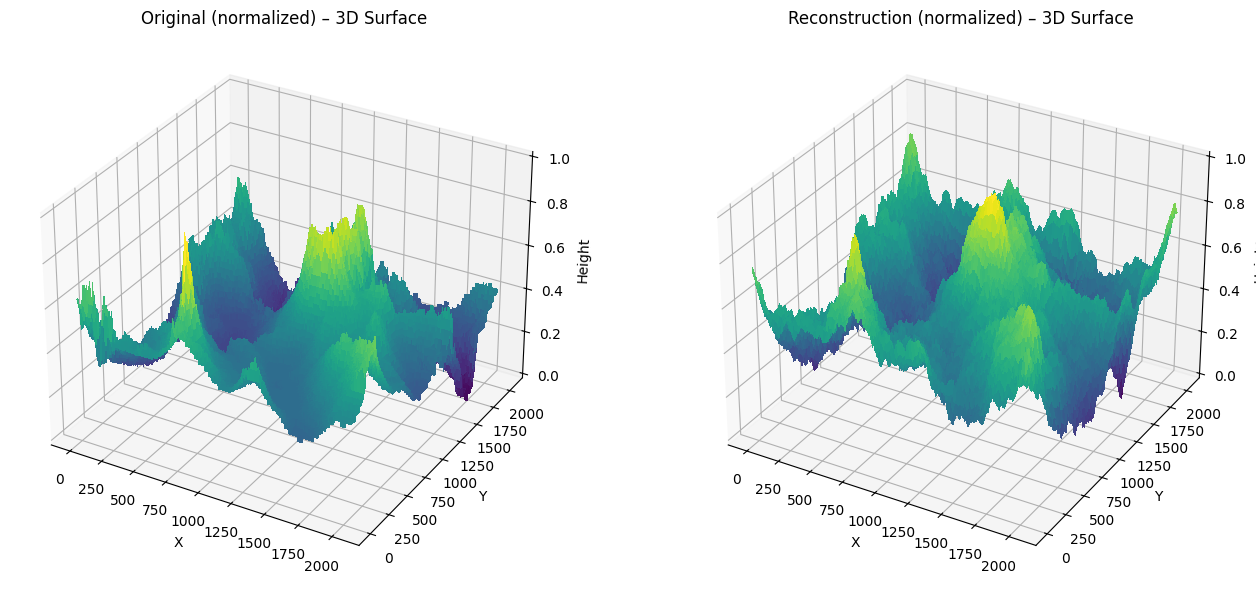

In [33]:
import numpy as np
import imageio.v2 as imageio
import matplotlib.pyplot as plt
from scipy.ndimage import zoom as ndzoom
from scipy.fftpack import fft2, fftshift
from mpl_toolkits.mplot3d import Axes3D

# 1) Compute fractal exponent H from the raw image
def compute_radial_psd(img):
    F2 = fftshift(fft2(img))
    P2 = np.abs(F2)**2
    ny, nx = P2.shape
    cy, cx = ny//2, nx//2
    y, x = np.indices((ny, nx))
    r = np.hypot(x - cx, y - cy).astype(int)
    max_r = min(cx, cy)
    bc = np.bincount(r.ravel(), minlength=max_r+1)[: max_r+1]
    bs = np.bincount(r.ravel(), P2.ravel(), minlength=max_r+1)[: max_r+1]
    radial_ps = bs[1:] / bc[1:]   # drop DC
    k_vals = np.arange(1, max_r+1)
    return k_vals, radial_ps

def fit_power_law_loglog(k, ps):
    mask = (ps > 0)
    logk = np.log10(k[mask])
    logps = np.log10(ps[mask])
    slope, intercept = np.polyfit(logk, logps, 1)
    beta = -slope
    a = 10**intercept
    return a, beta

def compute_fractal_H(img):
    k_vals, radial_ps = compute_radial_psd(img)
    a_fit, beta = fit_power_law_loglog(k_vals, radial_ps)
    return (beta - 1)/2  # H

# 2) Midpoint-only displacement (periodic) function
def midpoint_displacement(coarse, H, num_iters,sdim):
    grid = coarse.copy()
    sigma0 = coarse.max() - coarse.min()

    for i in range(num_iters):
        n = grid.shape[0]
        new_n = 2 * n
        new_grid = np.zeros((new_n, new_n), dtype=float)

        # Copy originals at even indices
        new_grid[0:new_n:2, 0:new_n:2] = grid

        # Scale of random offset
        amplitude = sigma0 * (2 ** (-(i+sdim) * H))

        # Horizontal midpoints (even row, odd col)
        for y in range(0, new_n, 2):
            for x in range(1, new_n, 2):
                left  = new_grid[y, x-1]
                right = new_grid[y, (x+1) % new_n]
                new_grid[y, x] = 0.5*(left + right) + np.random.uniform(-amplitude, amplitude)

        # Vertical midpoints (odd row, even col)
        for y in range(1, new_n, 2):
            for x in range(0, new_n, 2):
                top = new_grid[y-1, x]
                bot = new_grid[(y+1) % new_n, x]
                new_grid[y, x] = 0.5*(top + bot) + np.random.uniform(-amplitude, amplitude)

        # Cell centers (odd row, odd col)
        for y in range(1, new_n, 2):
            for x in range(1, new_n, 2):
                tl = new_grid[y-1, x-1]
                tr = new_grid[y-1, (x+1) % new_n]
                bl = new_grid[(y+1) % new_n, x-1]
                br = new_grid[(y+1) % new_n, (x+1) % new_n]
                avg = 0.25 * (tl + tr + bl + br)
                new_grid[y, x] = avg + np.random.uniform(-amplitude, amplitude)

        grid = new_grid

    return grid

# 3) Load and preprocess
img = imageio.imread("full.png")
if img.ndim == 3:
    img = img.mean(axis=2)
img = img.astype(np.float32)
h_full, w_full = img.shape

# 4) Compute H
H = compute_fractal_H(img)

# 5) Choose base_res = largest power-of-2 ≤ min dimension
min_dim = min(h_full, w_full)
exp_min = 4
base_res = 2**exp_min

# 6) Downsample original to base_res×base_res
coarse = ndzoom(img, (base_res/h_full, base_res/w_full), order=3, mode='wrap')
coarse = coarse[:base_res, :base_res]

# 7) Determine number of midpoint iterations to reach final_res ≤ max dimension
max_dim = max(h_full, w_full)
n = 0
while base_res * (2**n) <= max_dim:
    n += 1
n -= 1
final_res = base_res * (2**n)

# 8) Perform midpoint displacement
recon = midpoint_displacement(coarse, H, n,exp_min)

# 9) Downsample original for fair comparison
orig_down = ndzoom(img, (final_res/h_full, final_res/w_full), order=3, mode='wrap')
orig_down = orig_down[:final_res, :final_res]

# 10) Normalize both to [0,1]
orig_norm  = (orig_down - orig_down.min()) / (orig_down.max() - orig_down.min())
recon_norm = (recon - recon.min()) / (recon.max() - recon.min())

# 11) Build meshgrid for 3D plotting
X = np.arange(final_res)
Y = np.arange(final_res)
X2, Y2 = np.meshgrid(X, Y)

# 12) Plot side-by-side 3D surfaces
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(
    X2, Y2, orig_norm,
    cmap='viridis', rcount=100, ccount=100, linewidth=0, antialiased=False
)
ax1.set_title("Original (normalized) – 3D Surface")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Height")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(
    X2, Y2, recon_norm,
    cmap='viridis', rcount=100, ccount=100, linewidth=0, antialiased=False
)
ax2.set_title("Reconstruction (normalized) – 3D Surface")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Height")

plt.tight_layout()
plt.show()


In [22]:
base_res/w_full

1.0

Spectral slope β = 2.978, fractal exponent H = 0.989


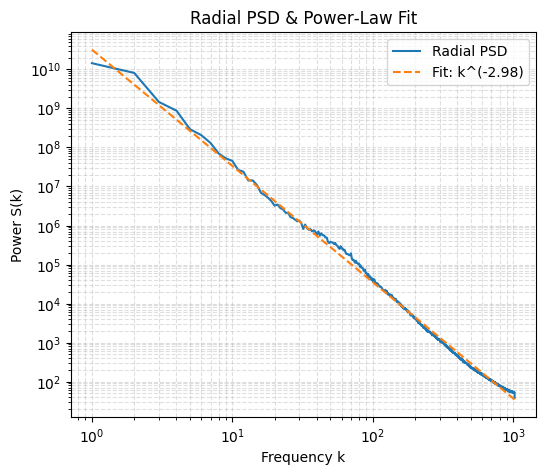

In [14]:
H, beta, k_vals, radial_ps, a_fit = compute_fractal_H(recon_norm)
print(f"Spectral slope β = {beta:.3f}, fractal exponent H = {H:.3f}")

# Plot PSD fit
plt.figure(figsize=(6,5))
plt.loglog(k_vals, radial_ps,         label="Radial PSD")
plt.loglog(k_vals, a_fit * k_vals**(-beta), '--',
           label=f"Fit: k^(-{beta:.2f})")
plt.xlabel("Frequency k")
plt.ylabel("Power S(k)")
plt.title("Radial PSD & Power‐Law Fit")
plt.legend()
plt.grid(which="both", ls="--", alpha=0.4)
plt.show()

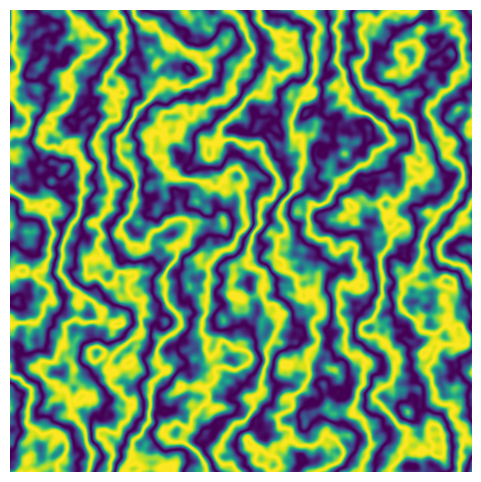

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from noise import pnoise2

# Parameters
width, height = 512, 512
scale = 5.0        # Controls noise frequency
stripe_freq = 20   # Controls stripe frequency
noise_amp = 0.3    # Amplitude of noise modulation

# Generate grid
x = np.linspace(0, 1, width)
y = np.linspace(0, 1, height)
X, Y = np.meshgrid(x, y)

# Generate Perlin noise
noise = np.zeros((height, width))
for i in range(height):
    for j in range(width):
        noise[i, j] = pnoise2(X[i, j] * scale, Y[i, j] * scale, octaves=4, persistence=0.5, lacunarity=2.0)

# Create wood-like texture by modulating sine stripes with noise
wood = np.sin((X + noise_amp * noise) * stripe_freq * np.pi)

# Display
plt.figure(figsize=(6, 6))
plt.imshow(wood)
plt.axis('off')
plt.show()


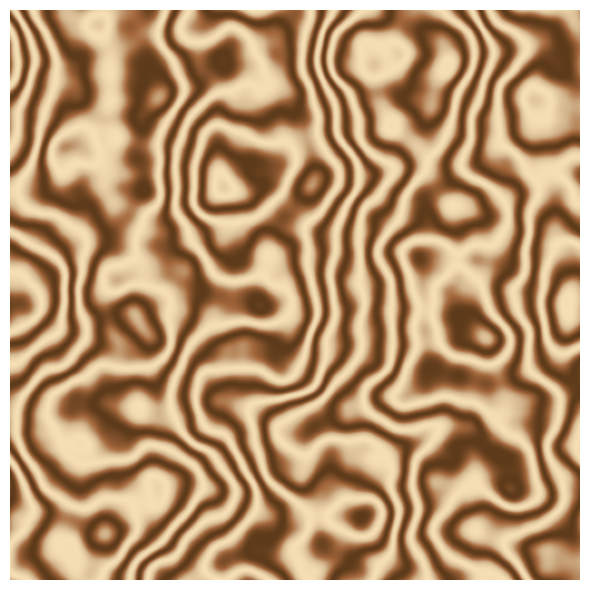

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Perlin noise helper functions
def fade(t):
    return 6*t**5 - 15*t**4 + 10*t**3

def lerp(a, b, t):
    return a + t * (b - a)

def grad(hash_val, x, y):
    h = hash_val & 7
    u = x if h < 4 else y
    v = y if h < 4 else x
    return (u if (h & 1) == 0 else -u) + (v if (h & 2) == 0 else -v)

# Build permutation table
perm = np.arange(256, dtype=int)
np.random.seed(0)
np.random.shuffle(perm)
perm = np.concatenate([perm, perm])

def perlin(x, y):
    xi, yi = int(np.floor(x)) & 255, int(np.floor(y)) & 255
    xf, yf = x - np.floor(x), y - np.floor(y)
    u, v = fade(xf), fade(yf)
    n00 = grad(perm[xi + perm[yi]], xf, yf)
    n01 = grad(perm[xi + perm[yi + 1]], xf, yf - 1)
    n10 = grad(perm[xi + 1 + perm[yi]], xf - 1, yf)
    n11 = grad(perm[xi + 1 + perm[yi + 1]], xf - 1, yf - 1)
    return lerp(lerp(n00, n10, u), lerp(n01, n11, u), v)

# Fractal (octave) noise function
def perlin_fractal(x, y, octaves=5, persistence=0.5, lacunarity=2.0):
    total = 0.0
    amplitude = 1.0
    frequency = 1.0
    max_amp = 0.0
    for _ in range(octaves):
        total += perlin(x * frequency, y * frequency) * amplitude
        max_amp += amplitude
        amplitude *= persistence
        frequency *= lacunarity
    return total / max_amp

# Texture parameters
width, height = 512, 512
scale = 5.0
stripe_freq = 20
noise_amp = 0.3
octaves = 3
persistence = 0.3
lacunarity = 2.0

# Generate wood-like texture with fractal noise
wood = np.zeros((height, width))
for i in range(height):
    for j in range(width):
        u = i / height * scale
        v = j / width * scale
        n = perlin_fractal(u, v, octaves, persistence, lacunarity)
        wood[i, j] = np.sin(((j / width) + noise_amp * n) * stripe_freq * np.pi)

# Wood-inspired colormap
wood_cmap = LinearSegmentedColormap.from_list(
    "wood",
    ["#5D3A1A", "#A4673C", "#D2B48C", "#F5DEB3"]
)

# Display
plt.figure(figsize=(6, 6))
plt.imshow(wood, cmap=wood_cmap)
plt.axis('off')
plt.tight_layout()
plt.show()


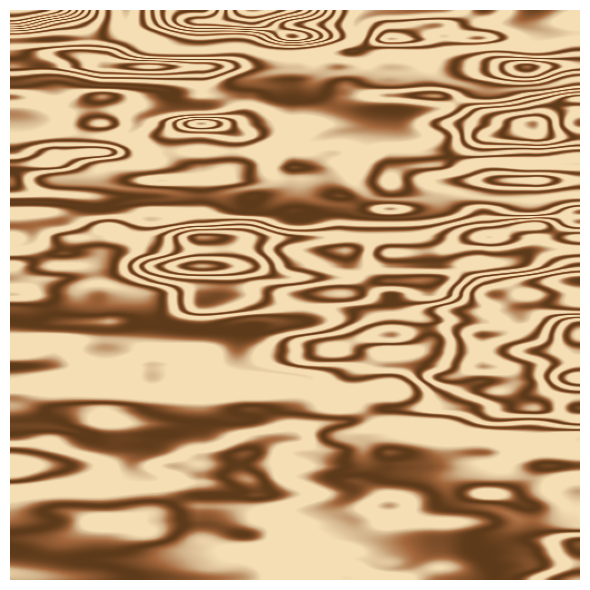

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ---------- Noise functions (Inigo Quilez / iq noise) ----------
def random2d(x, y):
    """Value noise random base."""
    return np.mod(np.sin(x * 12.9898 + y * 78.233) * 43758.5453123, 1.0)

def noise2d(x, y):
    """Smooth value noise."""
    i_x = np.floor(x)
    i_y = np.floor(y)
    f_x = x - i_x
    f_y = y - i_y
    u_x = f_x * f_x * (3.0 - 2.0 * f_x)
    u_y = f_y * f_y * (3.0 - 2.0 * f_y)
    
    n00 = random2d(i_x,     i_y)
    n10 = random2d(i_x + 1, i_y)
    n01 = random2d(i_x,     i_y + 1)
    n11 = random2d(i_x + 1, i_y + 1)
    
    x1 = n00 * (1 - u_x) + n10 * u_x
    x2 = n01 * (1 - u_x) + n11 * u_x
    return x1 * (1 - u_y) + x2 * u_y

def fractal_noise(x, y, octaves=3, persistence=0.5, lacunarity=2.0):
    """Sum of multiple noise layers."""
    total = np.zeros_like(x)
    amplitude = 1.0
    frequency = 1.0
    max_amp = 0.0
    for _ in range(octaves):
        total += noise2d(x * frequency, y * frequency) * amplitude
        max_amp += amplitude
        amplitude *= persistence
        frequency *= lacunarity
    return total / max_amp

# ---------- Stripe function (iq lines) ----------
def lines(pos_x, b=0.5, scale=10.0):
    val = np.abs(np.sin(pos_x * np.pi) + b * 2.0) * 0.5
    threshold = 0.5 + b * 0.5
    return np.clip(val / threshold, 0.0, 1.0)

# ---------- Setup grid ----------
width, height = 512, 512
i = np.arange(width)
j = np.arange(height)
X, Y = np.meshgrid(i / width, j / height)
# aspect correction
Y *= height / width

# position for stripes
pos_x = Y * 10.0
pos_y = X * 3.0

# ---------- Add fractal noise and rotate ----------
angle = fractal_noise(pos_x, pos_y) * 2 * np.pi
cosA = np.cos(angle)
sinA = np.sin(angle)
rot_x = cosA * pos_x - sinA * pos_y
rot_y = sinA * pos_x + cosA * pos_y

# ---------- Generate final pattern ----------
pattern = lines(rot_x)

# ---------- Apply wood colormap ----------
wood_cmap = LinearSegmentedColormap.from_list(
    "wood",
    ["#5D3A1A", "#A4673C", "#D2B48C", "#F5DEB3"]
)

plt.figure(figsize=(6, 6))
plt.imshow(pattern, cmap=wood_cmap, origin='lower')
plt.axis('off')
plt.tight_layout()
plt.show()


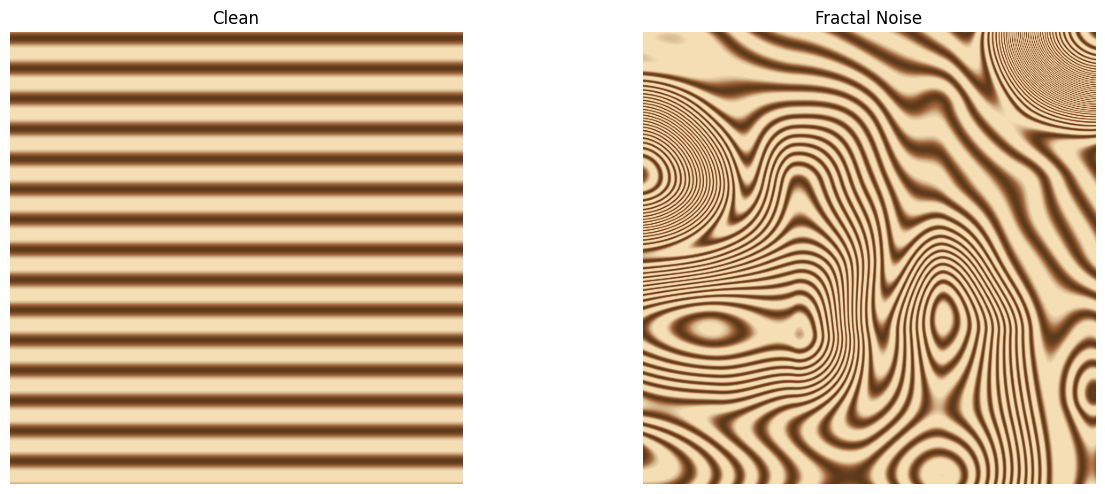

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ---------- IQ value noise functions ----------
def random2d(x, y):
    return np.mod(np.sin(x * 12.9898 + y * 78.233) * 43758.5453123, 1.0)

def noise2d(x, y):
    ix = np.floor(x)
    iy = np.floor(y)
    fx = x - ix
    fy = y - iy
    ux = fx * fx * (3.0 - 2.0 * fx)
    uy = fy * fy * (3.0 - 2.0 * fy)
    
    n00 = random2d(ix,     iy)
    n10 = random2d(ix + 1, iy)
    n01 = random2d(ix,     iy + 1)
    n11 = random2d(ix + 1, iy + 1)
    
    x1 = n00 * (1 - ux) + n10 * ux
    x2 = n01 * (1 - ux) + n11 * ux
    return x1 * (1 - uy) + x2 * uy

def fractal_noise(x, y, octaves=2, persistence=0.1, lacunarity=2.0):
    total = np.zeros_like(x)
    amplitude = 1.0
    frequency = 1.0
    max_amp = 0.0
    for _ in range(octaves):
        total += noise2d(x * frequency, y * frequency) * amplitude
        max_amp += amplitude
        amplitude *= persistence
        frequency *= lacunarity
    return total / max_amp

# ---------- Stripe function ----------
def lines(px, b=0.5, scale=10.0):
    px = px * scale
    val = np.abs(np.sin(px * np.pi) + b * 2.0) * 0.5
    thresh = 0.5 + b * 0.5
    return np.clip(val / thresh, 0.0, 1.0)

# ---------- Setup grid ----------
width, height = 512, 512
i = np.arange(width)
j = np.arange(height)
X, Y = np.meshgrid(i / width, j / height)
Y *= height / width  # aspect correction

pos_x = Y * 3.0
pos_y = X * 3.0

# ---------- Clean pattern ----------
pattern_clean = lines(pos_x)

# ---------- Noisy pattern with fractal noise ----------
angle = fractal_noise(pos_x, pos_y) * 2 * np.pi
cosA = np.cos(angle)
sinA = np.sin(angle)
rot_x = cosA * pos_x - sinA * pos_y
pattern_noisy = lines(rot_x)

# ---------- Wood colormap ----------
wood_cmap = LinearSegmentedColormap.from_list(
    "wood",
    ["#5D3A1A", "#A4673C", "#D2B48C", "#F5DEB3"]
)

# ---------- Plot side by side with separation ----------
fig, axs = plt.subplots(1, 2, figsize=(14, 8))
for ax, pattern, title in zip(axs, [pattern_clean, pattern_noisy], ['Clean', 'Fractal Noise']):
    ax.imshow(pattern, cmap=wood_cmap, origin='lower')
    ax.set_title(title)
    ax.axis('off')

# Increase separation
fig.subplots_adjust(wspace=0.4)
plt.show()


In [6]:
pattern_noisy.shape, angle.shape

((512, 512), (512, 512))

In [ ]:
import torchtt as tntt
import torch as tn



TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 256, 128, 64, 32, 16, 8, 4, 2, 1]

Device: cpu, dtype: torch.float64
#entries 699048 compression 2.666656494140625

In [14]:
tntt.TT(tn.tensor(pattern_noisy), [2,2]*9).round(1e-8), tntt.TT(zM(tn.tensor(pattern_noisy),9), [4]*9).round(1e-8),tntt.TT(tn.tensor(pattern_noisy)[ord,:], [2,2]*9).round(1e-8)

(TT with sizes and ranks:
 N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
 R = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 256, 128, 64, 32, 16, 8, 4, 2, 1]
 
 Device: cpu, dtype: torch.float64
 #entries 699048 compression 2.666656494140625,
 TT with sizes and ranks:
 N = [4, 4, 4, 4, 4, 4, 4, 4, 4]
 R = [1, 4, 16, 64, 256, 256, 64, 16, 4, 1]
 
 Device: cpu, dtype: torch.float64
 #entries 401952 compression 1.5333251953125,
 TT with sizes and ranks:
 N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
 R = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 256, 128, 64, 32, 16, 8, 4, 2, 1]
 
 Device: cpu, dtype: torch.float64
 #entries 699048 compression 2.666656494140625)

In [13]:
ord = bit_reverse_indices(9)
tntt.TT(tn.tensor(angle), [2,2]*9).round(1e-8), tntt.TT(zM(tn.tensor(angle),9), [4]*9).round(1e-8), tntt.TT(tn.tensor(angle)[ord,:], [2,2]*9).round(1e-8)

(TT with sizes and ranks:
 N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
 R = [1, 2, 4, 8, 16, 28, 28, 28, 19, 10, 8, 8, 8, 8, 8, 8, 4, 2, 1]
 
 Device: cpu, dtype: torch.float64
 #entries 6700 compression 0.0255584716796875,
 TT with sizes and ranks:
 N = [4, 4, 4, 4, 4, 4, 4, 4, 4]
 R = [1, 4, 16, 58, 53, 39, 28, 13, 4, 1]
 
 Device: cpu, dtype: torch.float64
 #entries 30596 compression 0.1167144775390625,
 TT with sizes and ranks:
 N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
 R = [1, 2, 4, 8, 8, 8, 8, 8, 8, 10, 8, 8, 8, 8, 8, 8, 4, 2, 1]
 
 Device: cpu, dtype: torch.float64
 #entries 1768 compression 0.006744384765625)

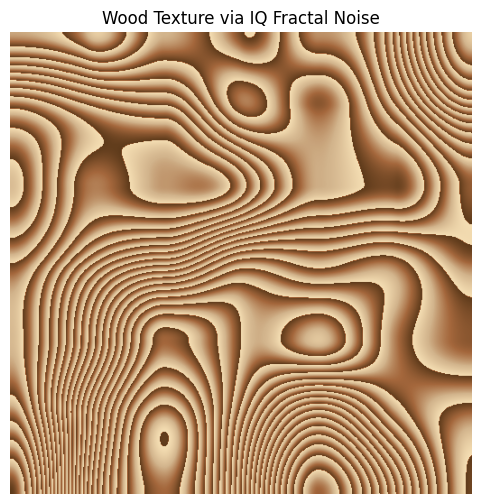

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ---------- IQ value noise functions ----------
def random2d(x, y):
    return np.mod(np.sin(x * 12.9898 + y * 78.233) * 43758.5453123, 1.0)

def noise2d(x, y):
    ix = np.floor(x)
    iy = np.floor(y)
    fx = x - ix
    fy = y - iy
    ux = fx * fx * (3.0 - 2.0 * fx)
    uy = fy * fy * (3.0 - 2.0 * fy)

    n00 = random2d(ix,     iy)
    n10 = random2d(ix + 1, iy)
    n01 = random2d(ix,     iy + 1)
    n11 = random2d(ix + 1, iy + 1)

    x1 = n00 * (1 - ux) + n10 * ux
    x2 = n01 * (1 - ux) + n11 * ux
    return x1 * (1 - uy) + x2 * uy

def fractal_noise(x, y, octaves=4, persistence=0.5, lacunarity=2.0):
    total = np.zeros_like(x)
    amplitude = 1.0
    frequency = 1.0
    max_amp = 0.0
    for _ in range(octaves):
        total += noise2d(x * frequency, y * frequency) * amplitude
        max_amp += amplitude
        amplitude *= persistence
        frequency *= lacunarity
    return total / max_amp

# ---------- Wood texture from IQ fractal noise ----------
def wood_texture_iq(x, y, octaves=4, persistence=0.5, lacunarity=2.0, rings=20):
    n = fractal_noise(x, y, octaves, persistence, lacunarity)
    rings_val = rings * n
    return rings_val - np.floor(rings_val)

# ---------- Setup grid ----------
dim = 512
lin = np.linspace(0, 3, dim, endpoint=False)  # scale noise domain
X, Y = np.meshgrid(lin, lin)

# Generate wood texture
wood = wood_texture_iq(X, Y, octaves=2, persistence=0.2, lacunarity=2.0, rings=30)

# ---------- Brown palette ----------
wood_cmap = LinearSegmentedColormap.from_list(
    "wood",
    ["#5D3A1A", "#A4673C", "#D2B48C", "#F5DEB3"]
)

# ---------- Render ----------
plt.figure(figsize=(6,6))
plt.imshow(wood, cmap=wood_cmap, origin='lower', interpolation='bilinear')
plt.axis('off')
plt.title("Wood Texture via IQ Fractal Noise")
plt.show()


In [18]:
ord = bit_reverse_indices(9)
tntt.TT(tn.tensor(wood), [2,2]*9).round(1e-8), tntt.TT(zM(tn.tensor(wood),9), [2,2]*9).round(1e-8), tntt.TT(tn.tensor(wood)[ord,:], [2,2]*9).round(1e-8)

(TT with sizes and ranks:
 N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
 R = [1, 2, 4, 8, 16, 32, 64, 128, 256, 507, 256, 128, 64, 32, 16, 8, 4, 2, 1]
 
 Device: cpu, dtype: torch.float64
 #entries 693928 compression 2.647125244140625,
 TT with sizes and ranks:
 N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
 R = [1, 2, 4, 8, 16, 32, 64, 128, 256, 495, 256, 128, 64, 32, 16, 8, 4, 2, 1]
 
 Device: cpu, dtype: torch.float64
 #entries 681640 compression 2.600250244140625,
 TT with sizes and ranks:
 N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
 R = [1, 2, 4, 8, 16, 32, 64, 128, 256, 507, 256, 128, 64, 32, 16, 8, 4, 2, 1]
 
 Device: cpu, dtype: torch.float64
 #entries 693928 compression 2.647125244140625)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# --- Utility functions ---
def random2d(x, y):
    return np.mod(np.sin(x * 12.9898 + y * 78.233) * 43758.5453123, 1.0)

def noise2d(x, y):
    ix = np.floor(x)
    iy = np.floor(y)
    fx = x - ix
    fy = y - iy
    ux = fx * fx * (3.0 - 2.0 * fx)
    uy = fy * fy * (3.0 - 2.0 * fy)
    n00 = random2d(ix, iy)
    n10 = random2d(ix + 1, iy)
    n01 = random2d(ix, iy + 1)
    n11 = random2d(ix + 1, iy + 1)
    x1 = n00 * (1 - ux) + n10 * ux
    x2 = n01 * (1 - ux) + n11 * ux
    return x1 * (1 - uy) + x2 * uy

def fractal_noise(x, y, octaves=4, persistence=0.5, lacunarity=2.0):
    total = np.zeros_like(x)
    amplitude = 1.0
    frequency = 1.0
    max_amp = 0.0
    for _ in range(octaves):
        total += noise2d(x * frequency, y * frequency) * amplitude
        max_amp += amplitude
        amplitude *= persistence
        frequency *= lacunarity
    return total / max_amp

def smoothstep(edge0, edge1, x):
    t = np.clip((x - edge0) / (edge1 - edge0), 0.0, 1.0)
    return t * t * (3.0 - 2.0 * t)

# --- Animation parameters ---
res = 256
frames = 200  # longer animation
fps = 20

# Create normalized grid
i = np.arange(res)
j = np.arange(res)
X, Y = np.meshgrid(i / res, j / res)

# scale coordinates
pos_x = X * 3.0
pos_y = Y * 3.0

# Setup figure
fig, ax = plt.subplots(figsize=(4, 4))
pattern = np.zeros((res, res))
im = ax.imshow(pattern, cmap='gray', vmin=0, vmax=1, origin='lower', animated=True)
ax.axis('off')

# Frame update function
def update(frame):
    t = frame * 0.05
    DF = fractal_noise(pos_x + t * 0.1, pos_y + t * 0.1) * 0.25 + 0.25
    a = fractal_noise(pos_x * np.cos(t * 0.15) * 0.1,
                      pos_y * np.sin(t * 0.1)  * 0.1) * np.pi
    DF += fractal_noise(pos_x + np.cos(a), pos_y + np.sin(a)) * 0.25 + 0.25
    patt = smoothstep(0.7, 0.75, np.mod(DF, 1.0))
    im.set_array(1.0 - patt)
    return [im]

# Create and save GIF
anim = FuncAnimation(fig, update, frames=frames, blit=True)
writer = PillowWriter(fps=fps)
anim.save('./stripes_fractal.gif', writer=writer)
plt.close(fig)


In [70]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# --- Value noise (Morgan McGuire style) ---
def random2d(x, y):
    return np.mod(np.sin(x * 12.9898 + y * 78.233) * 43758.5453123, 1.0)

def noise2d(x, y):
    ix = np.floor(x)
    iy = np.floor(y)
    fx = x - ix
    fy = y - iy
    ux = fx * fx * (3.0 - 2.0 * fx)
    uy = fy * fy * (3.0 - 2.0 * fy)
    
    n00 = random2d(ix,     iy)
    n10 = random2d(ix + 1, iy)
    n01 = random2d(ix,     iy + 1)
    n11 = random2d(ix + 1, iy + 1)
    
    x1 = n00 * (1 - ux) + n10 * ux
    x2 = n01 * (1 - ux) + n11 * ux
    return x1 * (1 - uy) + x2 * uy

# --- Fractal Brownian Motion ---
def fbm(x, y, octaves=5):
    v = np.zeros_like(x)
    amplitude = 0.5
    sx, sy = x.copy(), y.copy()
    # rotation matrix to reduce bias
    angle = 0.5
    c, s = np.cos(angle), np.sin(angle)
    for _ in range(octaves):
        v += amplitude * noise2d(sx, sy)
        # rotate and scale
        nx = c * sx - s * sy
        ny = s * sx + c * sy
        sx, sy = nx * 2.0 + 100.0, ny * 2.0 + 100.0
        amplitude *= 0.5
    return v

# --- Color mixing / smoothstep ---
def smoothstep(edge0, edge1, x):
    t = np.clip((x - edge0) / (edge1 - edge0), 0.0, 1.0)
    return t * t * (3.0 - 2.0 * t)

def mix(a, b, t):
    return a * (1 - t) + b * t

# --- Setup ---
res = 256
frames = 120
fps = 20

# normalized coords *3 as in shader
i = np.linspace(0, 1, res)
j = np.linspace(0, 1, res)
X, Y = np.meshgrid(i * 3.0, j * 3.0)

# precompute q (time-independent)
q_x = fbm(X, Y)
q_y = fbm(X + 1.0, Y + 1.0)

# color constants
col1 = np.array([0.101961, 0.619608, 0.666667])
col2 = np.array([0.666667, 0.666667, 0.498039])
col3 = np.array([0.0, 0.0, 0.164706])
col4 = np.array([0.666667, 1.0, 1.0])

# figure
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(np.zeros((res, res, 3)), origin='lower', animated=True)
ax.axis('off')

def update(frame):
    t = frame * 0.05
    # compute r
    r_x = fbm(X + q_x + 1.7 + 0.15 * t, Y + q_y + 9.2 + 0.15 * t)
    r_y = fbm(X + q_x + 8.3 + 0.126 * t, Y + q_y + 2.8 + 0.126 * t)
    # compute f
    f = fbm(X + r_x, Y + r_y)
    # base color mix
    mix_t = np.clip((f * f) * 4.0, 0.0, 1.0)
    color = mix(col1, col2, mix_t[..., None])
    # mix with dark blue by |q|
    q_len = np.sqrt(q_x**2 + q_y**2)
    color = mix(color, col3, np.clip(q_len, 0.0, 1.0)[..., None])
    # mix with light cyan by |r_x|
    color = mix(color, col4, np.clip(np.abs(r_x), 0.0, 1.0)[..., None])
    # final intensity
    intensity = (f**3 + 0.6 * f**2 + 0.5 * f)[..., None]
    frame_rgb = intensity * color
    im.set_array(frame_rgb)
    return [im]

anim = FuncAnimation(fig, update, frames=frames, blit=True)
writer = PillowWriter(fps=fps)
anim.save('./fbm_shader.gif', writer=writer)
plt.close(fig)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# --- Value noise (Morgan McGuire style) ---
def random2d(x, y):
    return np.mod(np.sin(x * 12.9898 + y * 78.233) * 43758.5453123, 1.0)

def noise2d(x, y):
    ix = np.floor(x)
    iy = np.floor(y)
    fx = x - ix
    fy = y - iy
    ux = fx * fx * (3.0 - 2.0 * fx)
    uy = fy * fy * (3.0 - 2.0 * fy)
    
    n00 = random2d(ix, iy)
    n10 = random2d(ix + 1, iy)
    n01 = random2d(ix, iy + 1)
    n11 = random2d(ix + 1, iy + 1)
    
    x1 = n00 * (1 - ux) + n10 * ux
    x2 = n01 * (1 - ux) + n11 * ux
    return x1 * (1 - uy) + x2 * uy

# --- Fractal Brownian Motion ---
def fbm(x, y, octaves=6):
    v = np.zeros_like(x)
    amplitude = 0.5
    sx, sy = x.copy(), y.copy()
    c, s = np.cos(0.5), np.sin(0.5)
    for _ in range(octaves):
        v += amplitude * noise2d(sx, sy)
        nx = c * sx - s * sy
        ny = s * sx + c * sy
        sx, sy = nx * 2.0 + 100.0, ny * 2.0 + 100.0
        amplitude *= 0.5
    return v

# --- Helpers ---
def smoothstep(edge0, edge1, x):
    t = np.clip((x - edge0) / (edge1 - edge0), 0.0, 1.0)
    return t * t * (3.0 - 2.0 * t)

def mix(a, b, t):
    return a * (1 - t) + b * t

# --- Setup ---
res = 512
frames = 200
fps = 15

i = np.linspace(0, 1, res)
j = np.linspace(0, 1, res)
X, Y = np.meshgrid(i * 3.0, j * 3.0)

q_x = fbm(X, Y)
q_y = fbm(X + 1.0, Y + 1.0)

col1 = np.array([0.101961, 0.619608, 0.666667])
col2 = np.array([0.666667, 0.666667, 0.498039])
col3 = np.array([0.0, 0.0, 0.164706])
col4 = np.array([0.666667, 1.0, 1.0])

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(np.zeros((res, res, 3)), origin='lower', animated=True)
ax.axis('off')

def update(frame):
    t = frame * 0.1
    r_x = fbm(X + q_x + 1.7 + 0.15 * t, Y + q_y + 9.2 + 0.15 * t)
    r_y = fbm(X + q_x + 8.3 + 0.126 * t, Y + q_y + 2.8 + 0.126 * t)
    f = fbm(X + r_x, Y + r_y)
    mix_t = np.clip((f * f) * 4.0, 0.0, 1.0)
    color = mix(col1, col2, mix_t[..., None])
    q_len = np.sqrt(q_x**2 + q_y**2)
    color = mix(color, col3, np.clip(q_len, 0.0, 1.0)[..., None])
    color = mix(color, col4, np.clip(np.abs(r_x), 0.0, 1.0)[..., None])
    intensity = (f**3 + 0.6 * f**2 + 0.5 * f)[..., None]
    frame_rgb = intensity * color
    im.set_array(frame_rgb)
    return [im]

anim = FuncAnimation(fig, update, frames=frames, blit=True)
writer = PillowWriter(fps=fps)
anim.save('./fbm_shader.gif', writer=writer)
plt.close(fig)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# --- Value noise (Morgan McGuire style) ---
def random2d(x, y):
    return np.mod(np.sin(x * 12.9898 + y * 78.233) * 43758.5453123, 1.0)

def noise2d(x, y):
    ix = np.floor(x)
    iy = np.floor(y)
    fx = x - ix
    fy = y - iy
    ux = fx * fx * (3.0 - 2.0 * fx)
    uy = fy * fy * (3.0 - 2.0 * fy)
    
    n00 = random2d(ix, iy)
    n10 = random2d(ix + 1, iy)
    n01 = random2d(ix, iy + 1)
    n11 = random2d(ix + 1, iy + 1)
    
    x1 = n00 * (1 - ux) + n10 * ux
    x2 = n01 * (1 - ux) + n11 * ux
    return x1 * (1 - uy) + x2 * uy

# --- Fractal Brownian Motion ---
def fbm(x, y, octaves=6):
    v = np.zeros_like(x)
    amplitude = 0.5
    sx, sy = x.copy(), y.copy()
    c, s = np.cos(0.5), np.sin(0.5)
    for _ in range(octaves):
        v += amplitude * noise2d(sx, sy)
        nx = c * sx - s * sy
        ny = s * sx + c * sy
        sx, sy = nx * 2.0 + 100.0, ny * 2.0 + 100.0
        amplitude *= 0.5
    return v

# --- Helpers ---
def smoothstep(edge0, edge1, x):
    t = np.clip((x - edge0) / (edge1 - edge0), 0.0, 1.0)
    return t * t * (3.0 - 2.0 * t)

def mix(a, b, t):
    return a * (1 - t) + b * t

# --- Parameters ---
scale_factor = 4
res_small = 256          # compute at low resolution
res = res_small * scale_factor
frames = 250               # same frame count
fps = 25                   # slower playback for longer duration

# Coordinate grid at low res
i = np.linspace(0, 1, res_small)
j = np.linspace(0, 1, res_small)
X, Y = np.meshgrid(i * 3.0, j * 3.0)

# Precompute q (shared across frames)
q_x = fbm(X, Y)
q_y = fbm(X + 1.0, Y + 1.0)

# Color constants
col1 = np.array([0.101961, 0.619608, 0.666667])
col2 = np.array([0.666667, 0.666667, 0.498039])
col3 = np.array([0.0, 0.0, 0.164706])
col4 = np.array([0.666667, 1.0, 1.0])

# Setup figure
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(np.zeros((res, res, 3)), origin='lower', animated=True)
ax.axis('off')

# Update function
def update(frame):
    t = frame * 0.05
    r_x = fbm(X + q_x + 1.7 + 0.15 * t, Y + q_y + 9.2 + 0.15 * t)
    r_y = fbm(X + q_x + 8.3 + 0.126 * t, Y + q_y + 2.8 + 0.126 * t)
    f = fbm(X + r_x, Y + r_y)
    
    # Color mixing
    mix_t = np.clip((f * f) * 4.0, 0.0, 1.0)
    color = mix(col1, col2, mix_t[..., None])
    q_len = np.sqrt(q_x**2 + q_y**2)
    color = mix(color, col3, np.clip(q_len, 0.0, 1.0)[..., None])
    color = mix(color, col4, np.clip(np.abs(r_x), 0.0, 1.0)[..., None])
    intensity = (f**3 + 0.6 * f**2 + 0.5 * f)[..., None]
    
    frame_small = intensity * color  # low-res color frame
    # upscale to high resolution
    frame_large = np.repeat(np.repeat(frame_small, scale_factor, axis=0), scale_factor, axis=1)
    
    im.set_array(frame_large)
    return [im]

# Create and save GIF
anim = FuncAnimation(fig, update, frames=frames, blit=True)
writer = PillowWriter(fps=fps)
anim.save('./fbm_shader_long.gif', writer=writer)
plt.close(fig)


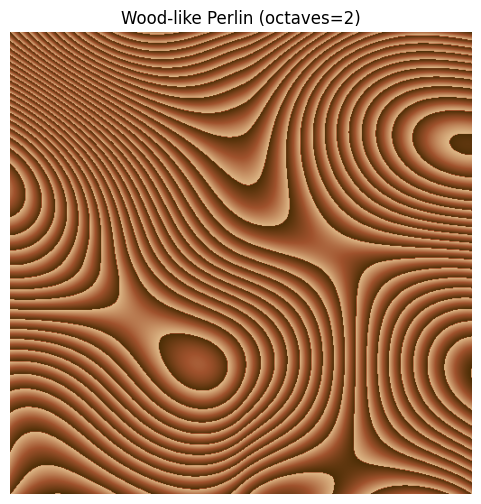

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Perlin noise setup
SIZE = 256
MASK = SIZE - 1

def init_perm(size=SIZE):
    """Initialize permutation table and gradient vectors."""
    perm = np.zeros(size, dtype=int)
    grads_x = np.zeros(size, dtype=float)
    grads_y = np.zeros(size, dtype=float)
    for i in range(size):
        j = np.random.randint(0, i + 1)
        if i > j:
            perm[i] = perm[j]
        perm[j] = i
        angle = 2 * np.pi * i / size
        grads_x[i] = np.cos(angle)
        grads_y[i] = np.sin(angle)
    return perm, grads_x, grads_y

def f(t):
    t = np.abs(t)
    return np.where(t >= 1.0, 0.0, 1.0 - (3.0 - 2.0*t)*(t**2))

def surflet(dx, dy, gx, gy):
    return f(dx) * f(dy) * (gx*dx + gy*dy)

def perlin(x, y, perm, gx, gy):
    """Single-frequency surflet-based Perlin noise."""
    ix, iy = np.floor(x).astype(int), np.floor(y).astype(int)
    n = 0.0
    for dy in [0, 1]:
        for dx in [0, 1]:
            h = perm[(perm[(ix + dx) & MASK] + (iy + dy)) & MASK]
            n += surflet(x - (ix + dx), y - (iy + dy), gx[h], gy[h])
    return n

def fractal_perlin(x, y, perm, gx, gy, octaves=4, persistence=0.5):
    """Combine multiple octaves of Perlin noise."""
    total = np.zeros_like(x, dtype=float)
    amplitude = 1.0
    frequency = 1.0
    max_amp = 0.0
    for _ in range(octaves):
        total += amplitude * perlin(x * frequency, y * frequency, perm, gx, gy)
        max_amp += amplitude
        amplitude *= persistence
        frequency *= 2
    return total / max_amp

def wood_texture(x, y, perm, gx, gy, octaves=4, persistence=0.5, rings=20):
    """Generate wood pattern from fractal Perlin noise."""
    n = fractal_perlin(x, y, perm, gx, gy, octaves, persistence)
    # Map from (-1,1) to (0,1)
    n = 0.5 * (n + 1.0)
    # Create rings
    rings_val = rings * n
    return rings_val - np.floor(rings_val)

def render_wood(dimension=500, octaves=4, persistence=0.5, rings=20):
    perm, gx, gy = init_perm()
    # Coordinate grid
    lin = np.linspace(0, 1, dimension, endpoint=False)
    X, Y = np.meshgrid(lin, lin)
    # Generate wood texture
    wood = wood_texture(X, Y, perm, gx, gy, octaves, persistence, rings)
    
    # Define brown palette
    brown_colors = ["#4b2e05", "#a0522d", "#deb887"]
    cmap = LinearSegmentedColormap.from_list("brown_wood", brown_colors)
    
    plt.figure(figsize=(6,6))
    plt.axis('off')
    plt.imshow(wood, cmap=cmap, interpolation='bilinear')
    plt.title(f"Wood-like Perlin (octaves={octaves})")
    plt.show()

# Example: render a 1000x1000 wood texture with 6 octaves
render_wood(dimension=512, octaves=2, persistence=0.5, rings=100)
